# RAG form scratch

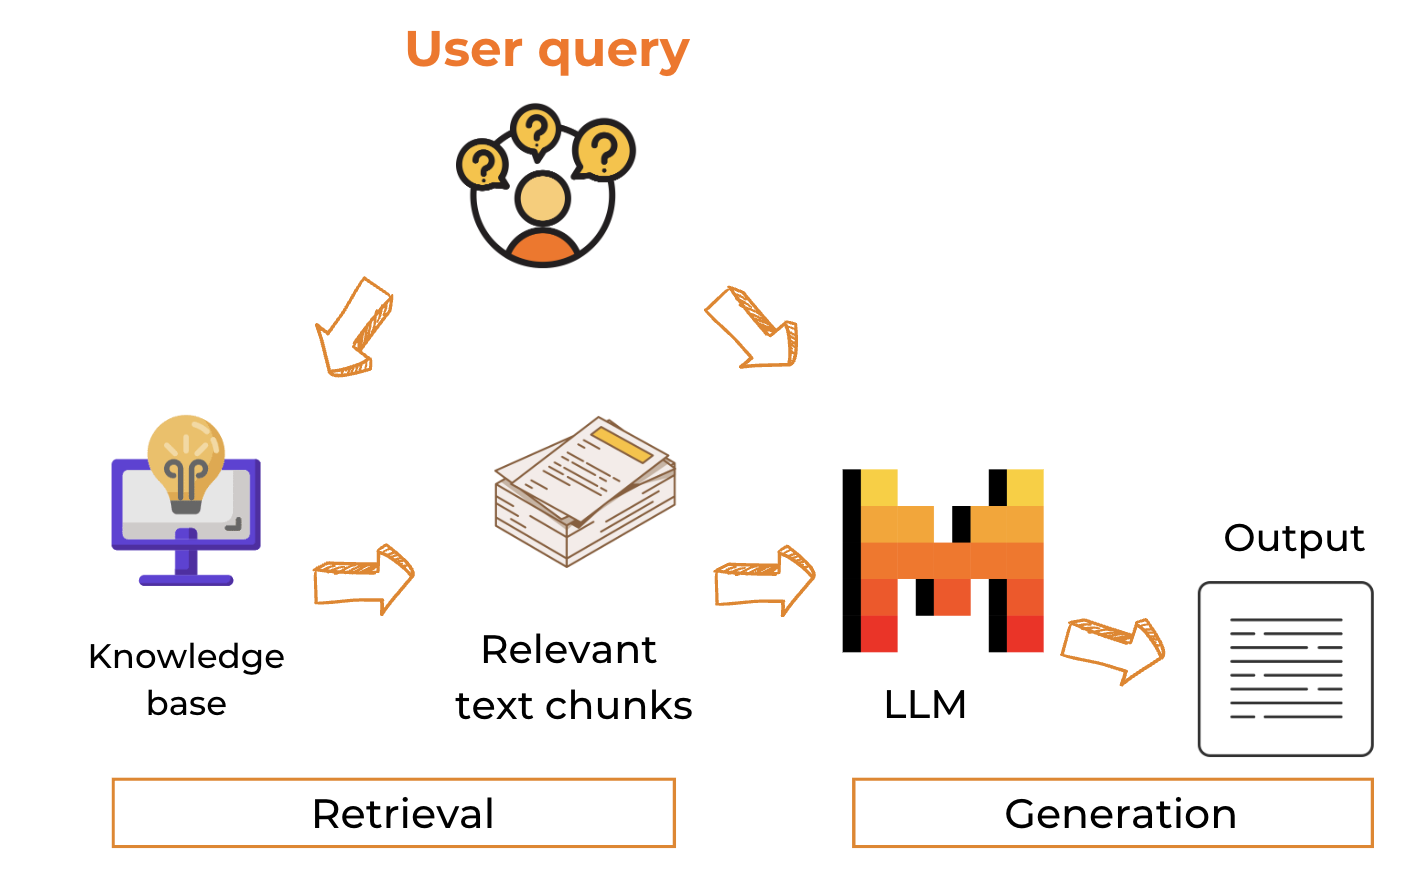

Retrieval-augmented generation (RAG) is an AI framework that synergizes the capabilities of LLMs and information retrieval systems. It’s useful to answer questions or generate content leveraging external knowledge. There are two main steps in RAG: 1) retrieval: retrieve relevant information from a knowledge base with text embeddings stored in a vector store; 2) generation: insert the relevant information to the prompt for the LLM to generate information. In this guide, we will walk through a very basic example of RAG with four implementations:

- RAG from scratch with sentence transformers embedding and OpenAI
- RAG with LangChain

## RAG from scratch

This section aims to guide you through the process of building a basic RAG from scratch. We have two goals: firstly, to offer users a comprehensive understanding of the internal workings of RAG and demystify the underlying mechanisms; secondly, to empower you with the essential foundations needed to build an RAG using the minimum required dependencies.


### Import needed packages
The first step is to install the needed packages and import the needed packages:

openai

sentence-transformers

langchain

langchain_openai

langchain_community

chromadb

numpy

scikit-learn


In [ ]:
# Import needed packages
!pip install openai numpy scikit-learn sentence-transformers langchain langchain_openai langchain-huggingface langchain_community chromadb -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.1/420.1 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 84.0 MB/s eta 0:00

In [ ]:
from openai import OpenAI
import requests
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import os
from getpass import getpass
from sentence_transformers import SentenceTransformer

In [ ]:
# Set up OpenAI client
api_key = getpass("Type your OpenAI API Key")
client = OpenAI(api_key=api_key)

Type your OpenAI API Key··········


### Get data

In this very simple example, we are getting data from an essay written by Paul Graham:

In [ ]:
# Get data from Paul Graham's essay
response = requests.get('https://raw.githubusercontent.com/run-llama/llama_index/main/docs/docs/examples/data/paul_graham/paul_graham_essay.txt')
text = response.text


We can also save the essay in a local file:

In [ ]:
# Save the essay in a local file
with open('essay.txt', 'w') as f:
    f.write(text)

Let's check the number of characters in the essay.

In [ ]:
print(f"Essay length: {len(text)} characters")

Essay length: 75014 characters


## Split document into chunks

In a RAG system, it is crucial to split the document into smaller chunks so that it’s more effective to identify and retrieve the most relevant information in the retrieval process later.

#### Considerations:
- **Chunk size**: Depending on your specific use case, it may be necessary to customize or experiment with different chunk sizes and chunk overlap to achieve optimal performance in RAG. For example, smaller chunks can be more beneficial in retrieval processes, as larger text chunks often contain filler text that can obscure the semantic representation. As such, using smaller text chunks in the retrieval process can enable the RAG system to identify and extract relevant information more effectively and accurately.  However, it’s worth considering the trade-offs that come with using smaller chunks, such as increasing processing time and computational resources.
- **How to split**: While the simplest method is to split the text by character, there are other options depending on the use case and document structure. For example, to avoid exceeding token limits in API calls, it may be necessary to split the text by tokens. To maintain the cohesiveness of the chunks, it can be useful to split the text by sentences, paragraphs, or HTML headers. If working with code, it’s often recommended to split by meaningful code chunks for example using an Abstract Syntax Tree (AST) parser.

In this example, we simply split our text by character, combine 2048 characters into each chunk, and we get 37 chunks.

In [ ]:
# Split document into chunks
chunk_size = 2048
chunks = [text[i:i + chunk_size] for i in range(0, len(text), chunk_size)]
print(f"Number of chunks: {len(chunks)}")

Number of chunks: 37


We have 37 chunks. Every chunk will be converted into numerical space as a vector embedding. How to do it?

### 🔍 Create Embeddings for Each Text Chunk
For each text chunk, we need to generate embeddings—numeric representations of text in vector space. Words or sentences with similar meanings should be closer together in this space.

To create embeddings, we can use any LLM. In this notebook, we’ll use sentence embeddings generated with the [SentenceTransformers](https://www.sbert.net/) library. It’s a powerful and widely used open-source tool for creating high-quality embeddings.

We use SentenceTransformers because it's:

- Open source – no license or API costs
- Lightweight – can be computed locally without calling an external API
- Flexible – supports a variety of pre-trained models optimized for semantic similarity

⚠️ Keep in mind: embedding chunks with commercial LLMs can be costly. For example, embedding this text with an OpenAI API might cost around $5—and the price increases with document size.

💡 Pro tip: it's more efficient to perform chunking and embedding once, then store the results in a vector database for reuse.

In [ ]:
# Load the SentenceTransformer model (for embeddings)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 🧠 Choosing an Embedding Model
Here we use one of the **smallest and most lightweight models**, 'all-MiniLM-L6-v2', which produces **384-dimensional vectors**.

It's fast, resource-efficient, and great for many practical use cases.


Different embedding models generate vectors of different dimensions:

'all-mpnet-base-v2' produces 768-dimensional vectors

'paraphrase-albert-small-v2' produces 768-dimensional vectors

'all-distilroberta-v1' produces 768-dimensional vectors

OpenAI's 'text-embedding-3-small' produces 1536-dimensional vectors

OpenAI's 'text-embedding-3-large' produces 3072-dimensional vectors


The embedding **dimension size** often reflects the **complexity and capability** of the model.

- **Larger dimensions** can capture more nuanced semantic information.
- But they also require **more memory and compute resources.**


🔍 When implementing **RAG** systems, selecting the right embedding model is crucial—it directly affects **performance**, **quality**, and **resource usage**.

After loading the Sentence Transformers library, we create a function to get text embeddings using them.

In [ ]:
# Create a function to get text embeddings using SentenceTransformers
def get_text_embedding(input_text):
    return embedding_model.encode(input_text)


## 🧩 Generate Embeddings for All Text Chunks
In this step, we iterate through each text chunk and generate its corresponding embedding using our **get_text_embedding()** function above. The embeddings are stored in a NumPy array, where each row represents a chunk, and each column corresponds to a dimension of the embedding space.

This process gives us a structured numerical representation of the entire document, which can be used for semantic search, clustering, or retrieval tasks.

In [ ]:
# Create embeddings for each text chunk
text_embeddings = []
for i, chunk in enumerate(chunks):
    print(f"Processing chunk {i+1}/{len(chunks)}")
    embedding = get_text_embedding(chunk)
    text_embeddings.append(embedding)

text_embeddings = np.array(text_embeddings)
print(f"Embeddings shape: {text_embeddings.shape}")

Processing chunk 1/37
Processing chunk 2/37
Processing chunk 3/37
Processing chunk 4/37
Processing chunk 5/37
Processing chunk 6/37
Processing chunk 7/37
Processing chunk 8/37
Processing chunk 9/37
Processing chunk 10/37
Processing chunk 11/37
Processing chunk 12/37
Processing chunk 13/37
Processing chunk 14/37
Processing chunk 15/37
Processing chunk 16/37
Processing chunk 17/37
Processing chunk 18/37
Processing chunk 19/37
Processing chunk 20/37
Processing chunk 21/37
Processing chunk 22/37
Processing chunk 23/37
Processing chunk 24/37
Processing chunk 25/37
Processing chunk 26/37
Processing chunk 27/37
Processing chunk 28/37
Processing chunk 29/37
Processing chunk 30/37
Processing chunk 31/37
Processing chunk 32/37
Processing chunk 33/37
Processing chunk 34/37
Processing chunk 35/37
Processing chunk 36/37
Processing chunk 37/37
Embeddings shape: (37, 384)


We got (37, 384) shape

📏 **Note**:
The first number in the embedding shape will match the number of text chunks you're processing.
The second number depends on the model you choose.

Let's take a look at how our text chunks are represented in numerical vector space. Below is the numerical representation (embedding vectors) of our text chunks, where each row corresponds to a chunk and each column to a dimension in the embedding space.

In [ ]:
text_embeddings

array([[-0.03938634,  0.03998332, -0.01110206, ...,  0.05104427,
        -0.03537319, -0.01781102],
       [-0.00872342,  0.02663906,  0.02401975, ..., -0.04489643,
        -0.09426064,  0.02063635],
       [-0.01820678, -0.09953736,  0.04833143, ...,  0.08998464,
        -0.01293661, -0.00487227],
       ...,
       [-0.02641056, -0.06703643,  0.05794968, ...,  0.09049086,
         0.03364922,  0.01212662],
       [-0.02667149, -0.08202592,  0.01562478, ..., -0.15434498,
         0.02901866, -0.05016329],
       [-0.1112404 , -0.12835729,  0.01407897, ...,  0.01452233,
         0.03544299, -0.01008185]], dtype=float32)

##❓ Embed the User Question
We now embed the user's question using the same embedding model as we used for the text chunks. This ensures that both the question and the document chunks exist in the same vector space, making it possible to compare them meaningfully (via cosine similarity).
The result is a single vector representing the semantic meaning of the question.

In [ ]:
# Create embedding for a question
question = "What were the two main things the author worked on before college?"
question_embedding = np.array([get_text_embedding(question)])
print(f"Question embedding shape: {question_embedding.shape}")

Question embedding shape: (1, 384)


The question embedding has the shape (1, 384), meaning it's a single vector with 384 dimensions—matching the dimensionality of our text chunk embeddings. This allows for direct comparison between the question and each chunk in vector space.

##📐 Compute Similarity Between the Question and All Text Chunks
We use cosine similarity to compare the question embedding with each chunk embedding. This gives us a similarity score for each chunk, indicating how semantically close it is to the question. Higher scores mean greater relevance.

The result is a 1D array where each value corresponds to the similarity between the question and a specific text chunk.

In [ ]:
# Calculate cosine similarity between question and all chunks
similarities = cosine_similarity(question_embedding, text_embeddings)[0]

##🔎 Retrieve the Most Relevant Chunks
We now identify the **top k** **most similar chunks** based on the cosine similarity scores.
We retrieve the **top 3 most similar text chunks** based on cosine similarity with the question embedding.

Using np.argsort(similarities)[-k:][::-1], we:

- Sort the similarity scores
- Take the indices of the **top k=3 highest scores**
- Reverse the order to get them in **descending relevance**

We then print the indices and their corresponding similarity scores.



In [ ]:
# Get the indices of the k most similar chunks
k = 3  # Number of chunks to retrieve
top_k_indices = np.argsort(similarities)[-k:][::-1]  # Sort and take top k
print(f"Retrieved chunk indices: {top_k_indices}")
print(f"Similarity scores: {similarities[top_k_indices]}")


Retrieved chunk indices: [ 0  5 10]
Similarity scores: [0.3729747  0.35623193 0.34145802]


We can see that the most relevant chunks are at indices **0**, **5** and **10**, with similarity scores of **0.37**, **0.36** and **0.34** respectively. These are the chunks that are most semantically similar to the user's question and would be good candidates for retrieval in a RAG system.

In [ ]:
# Get the retrieved chunks based on the indices
retrieved_chunks = [chunks[i] for i in top_k_indices]

##📄 Display Retrieved Chunks
Let’s display the top retrieved chunks in a more readable format. We'll show each chunk with a label and trim the content for clarity.

**Tip**: You can adjust [:1000] to a shorter or longer preview depending on how much text you want to show.

In [ ]:
# Display the top retrieved chunks in a readable way
print("Top Retrieved Chunks:\n")
for i, chunk in enumerate(retrieved_chunks):
    print(f"--- Chunk #{i + 1} ---")
    print(chunk.strip()[:1000])  # Show first 1000 characters for brevity
    print()


Top Retrieved Chunks:

--- Chunk #1 ---
What I Worked On

February 2021

Before college the two main things I worked on, outside of school, were writing and programming. I didn't write essays. I wrote what beginning writers were supposed to write then, and probably still are: short stories. My stories were awful. They had hardly any plot, just characters with strong feelings, which I imagined made them deep.

The first programs I tried writing were on the IBM 1401 that our school district used for what was then called "data processing." This was in 9th grade, so I was 13 or 14. The school district's 1401 happened to be in the basement of our junior high school, and my friend Rich Draves and I got permission to use it. It was like a mini Bond villain's lair down there, with all these alien-looking machines — CPU, disk drives, printer, card reader — sitting up on a raised floor under bright fluorescent lights.

The language we used was an early version of Fortran. You had to type program

We now printed the top retrieved chunks in a readable format. Each chunk is labeled and trimmed to the first 1000 characters to keep the notebook output clean. These are the passages most relevant to the user's question, based on cosine similarity with the question embedding.

##**Considerations:**
- **Retrieval methods**:
There are a lot different retrieval strategies. In our example, we are showing a simple similarity search with embeddings. Sometimes when there is metadata available for the data, it’s better to filter the data based on the metadata first before performing similarity search. There are also other statistical retrieval methods like TF-IDF and BM25 that use frequency and distribution of terms in the document to identify relevant text chunks.
- **Retrieved document**: Do we always retrieve individual text chunk as it is? Not always.
    - Sometimes, we would like to include more context around the actual retrieved text chunk. We call the actual retrieve text chunk “child chunk” and our goal is to retrieve a larger “parent chunk” that the “child chunk” belongs to.
    - On occasion, we might also want to provide weights to our retrieve documents. For example, a time-weighted approach would help us retrieve the most recent document.
    - One common issue in the retrieval process is the “lost in the middle” problem where the information in the middle of a long context gets lost. Our models have tried to mitigate this issue. For example, in the passkey task, our models have demonstrated the ability to find a "needle in a haystack" by retrieving a randomly inserted passkey within a long prompt, up to 32k context length. However, it is worth considering experimenting with reordering the document to determine if placing the most relevant chunks at the beginning and end leads to improved results.

##🔧 Construct the Prompt for the LLM
We now combine the **retrieved chunks** (context) and the **user’s question** into a single prompt. This prompt is designed to guide the language model to answer based **only on the provided context**, not any prior knowledge.

The structure of the prompt clearly separates:

- Context information (retrieved chunks)
- The actual user query
- Instructions to rely solely on the context

In [ ]:
# Combine context and question into a prompt for the language model
prompt = f"""
Context information is below.
---------------------
{retrieved_chunks}
---------------------
Given the context information and not prior knowledge, answer the query.
Query: {question}
Answer:
"""


##**How the prompt is structured?**
The prompt is structured to clearly separate **context**, **instructions**, and the **user's question**. This helps the language model focus only on the provided information, improving relevance and accuracy.

🔹 **Context information**
The retrieved_chunks section provides background knowledge retrieved from the document. This is what the model should use to form its answer.

🔹 **Instruction to the model**

“Given the context information and not prior knowledge…”
This tells the model to ignore external knowledge and rely only on the chunks provided—important for transparency and controlled response generation.

🔹 **Query and Answer prompt**
The user's question is introduced explicitly, followed by "Answer:", which prompts the model to continue by generating the answer.

##🤖 Generate an Answer Using OpenAI
We define a helper function to send the constructed prompt to **OpenAI's GPT-3.5-Turbo** and receive a response. The model is instructed to act as a helpful assistant and answer based on the input prompt.

In [ ]:
# Function to get a response from OpenAI
def generate_answer(prompt):
  # Use OpenAI for generation
  response = client.chat.completions.create(
      model="gpt-3.5-turbo",
      messages=[
          {"role": "system", "content": "You are a helpful assistant."},
          {"role": "user", "content": prompt}
          ]
      )
  return response.choices[0].message.content


**How it works:**

- The *system* message sets the tone or behavior for the assistant.
- The *user* message contains the full prompt (context + question).
- The function returns only the model’s textual answer.


## 💬 Generate and Display the Answer
Now we send the prompt to the OpenAI model using the generate_answer() function and print the resulting response.
This is the model’s answer to the user's question based **only on the retrieved context.**

In [ ]:
# Generate a response
response = generate_answer(prompt)
print("\nResponse:")
print(response)




Response:
Before college, the author worked on two main things outside of school: writing and programming.


🧪 **Tip**: Try changing the question or the embedding model to see how the response changes!

Let's change the prompt so the model provides a richer and more complete answer.

In [ ]:
# Create a more detailed prompt
detailed_prompt = f"""
You are a helpful assistant. Use only the information provided in the context below to answer the question as clearly and thoroughly as possible.

Context:
---------------------
{retrieved_chunks}
---------------------

Do not use any prior knowledge or external information. If the answer is not present in the context, respond with "The information is not available in the provided context."

Question: {question}

Detailed Answer:
"""


✅ What's improved:
- **Tone and instruction**: Starts with a system-like message for clarity: “You are a helpful assistant…”
- **Clear boundaries**: Strong emphasis on using only the given context.
- **Fallback behavior**: Explicitly tells the model what to do if the answer isn’t found (“The information is not available…”).
- **Encouragement to elaborate**: The prompt ends with "Detailed Answer:", nudging the model to provide a more in-depth reply.

In [ ]:
# Generate a response
response = generate_answer(detailed_prompt)
print("\nResponse:")
print(response)



Response:
Before college, the author worked on two main things outside of school: writing and programming. They specifically mentioned that they wrote short stories and also tried writing programs on the IBM 1401 using an early version of Fortran.


#Part 2: ⚙️ **RAG with LangChain**

In this section, we implement RAG using the LangChain framework. LangChain helps streamline the process of combining document retrieval with language model responses in a modular and production-friendly way.

## Overview
A typical RAG application has two main components:

**Indexing**: a pipeline for ingesting data from a source and indexing it.

**Retrieval and generation**: the actual RAG chain, which takes the user query at run time and retrieves the relevant data from the index, then passes that to the model.

### Indexing
1. **Load**: First we need to load our data. This is done with [Document Loaders](https://python.langchain.com/docs/concepts/document_loaders/).
2. **Split**: [Text splitters](https://python.langchain.com/docs/concepts/text_splitters/) break large `Documents` into smaller chunks. This is useful both for indexing data and passing it into a model, as large chunks are harder to search over and won't fit in a model's finite context window.
3. **Store**: We need somewhere to store and index our splits, so that they can be searched over later. This is often done using a [VectorStore](https://python.langchain.com/docs/concepts/vectorstores/) and [Embeddings](https://python.langchain.com/docs/concepts/embedding_models/) model.


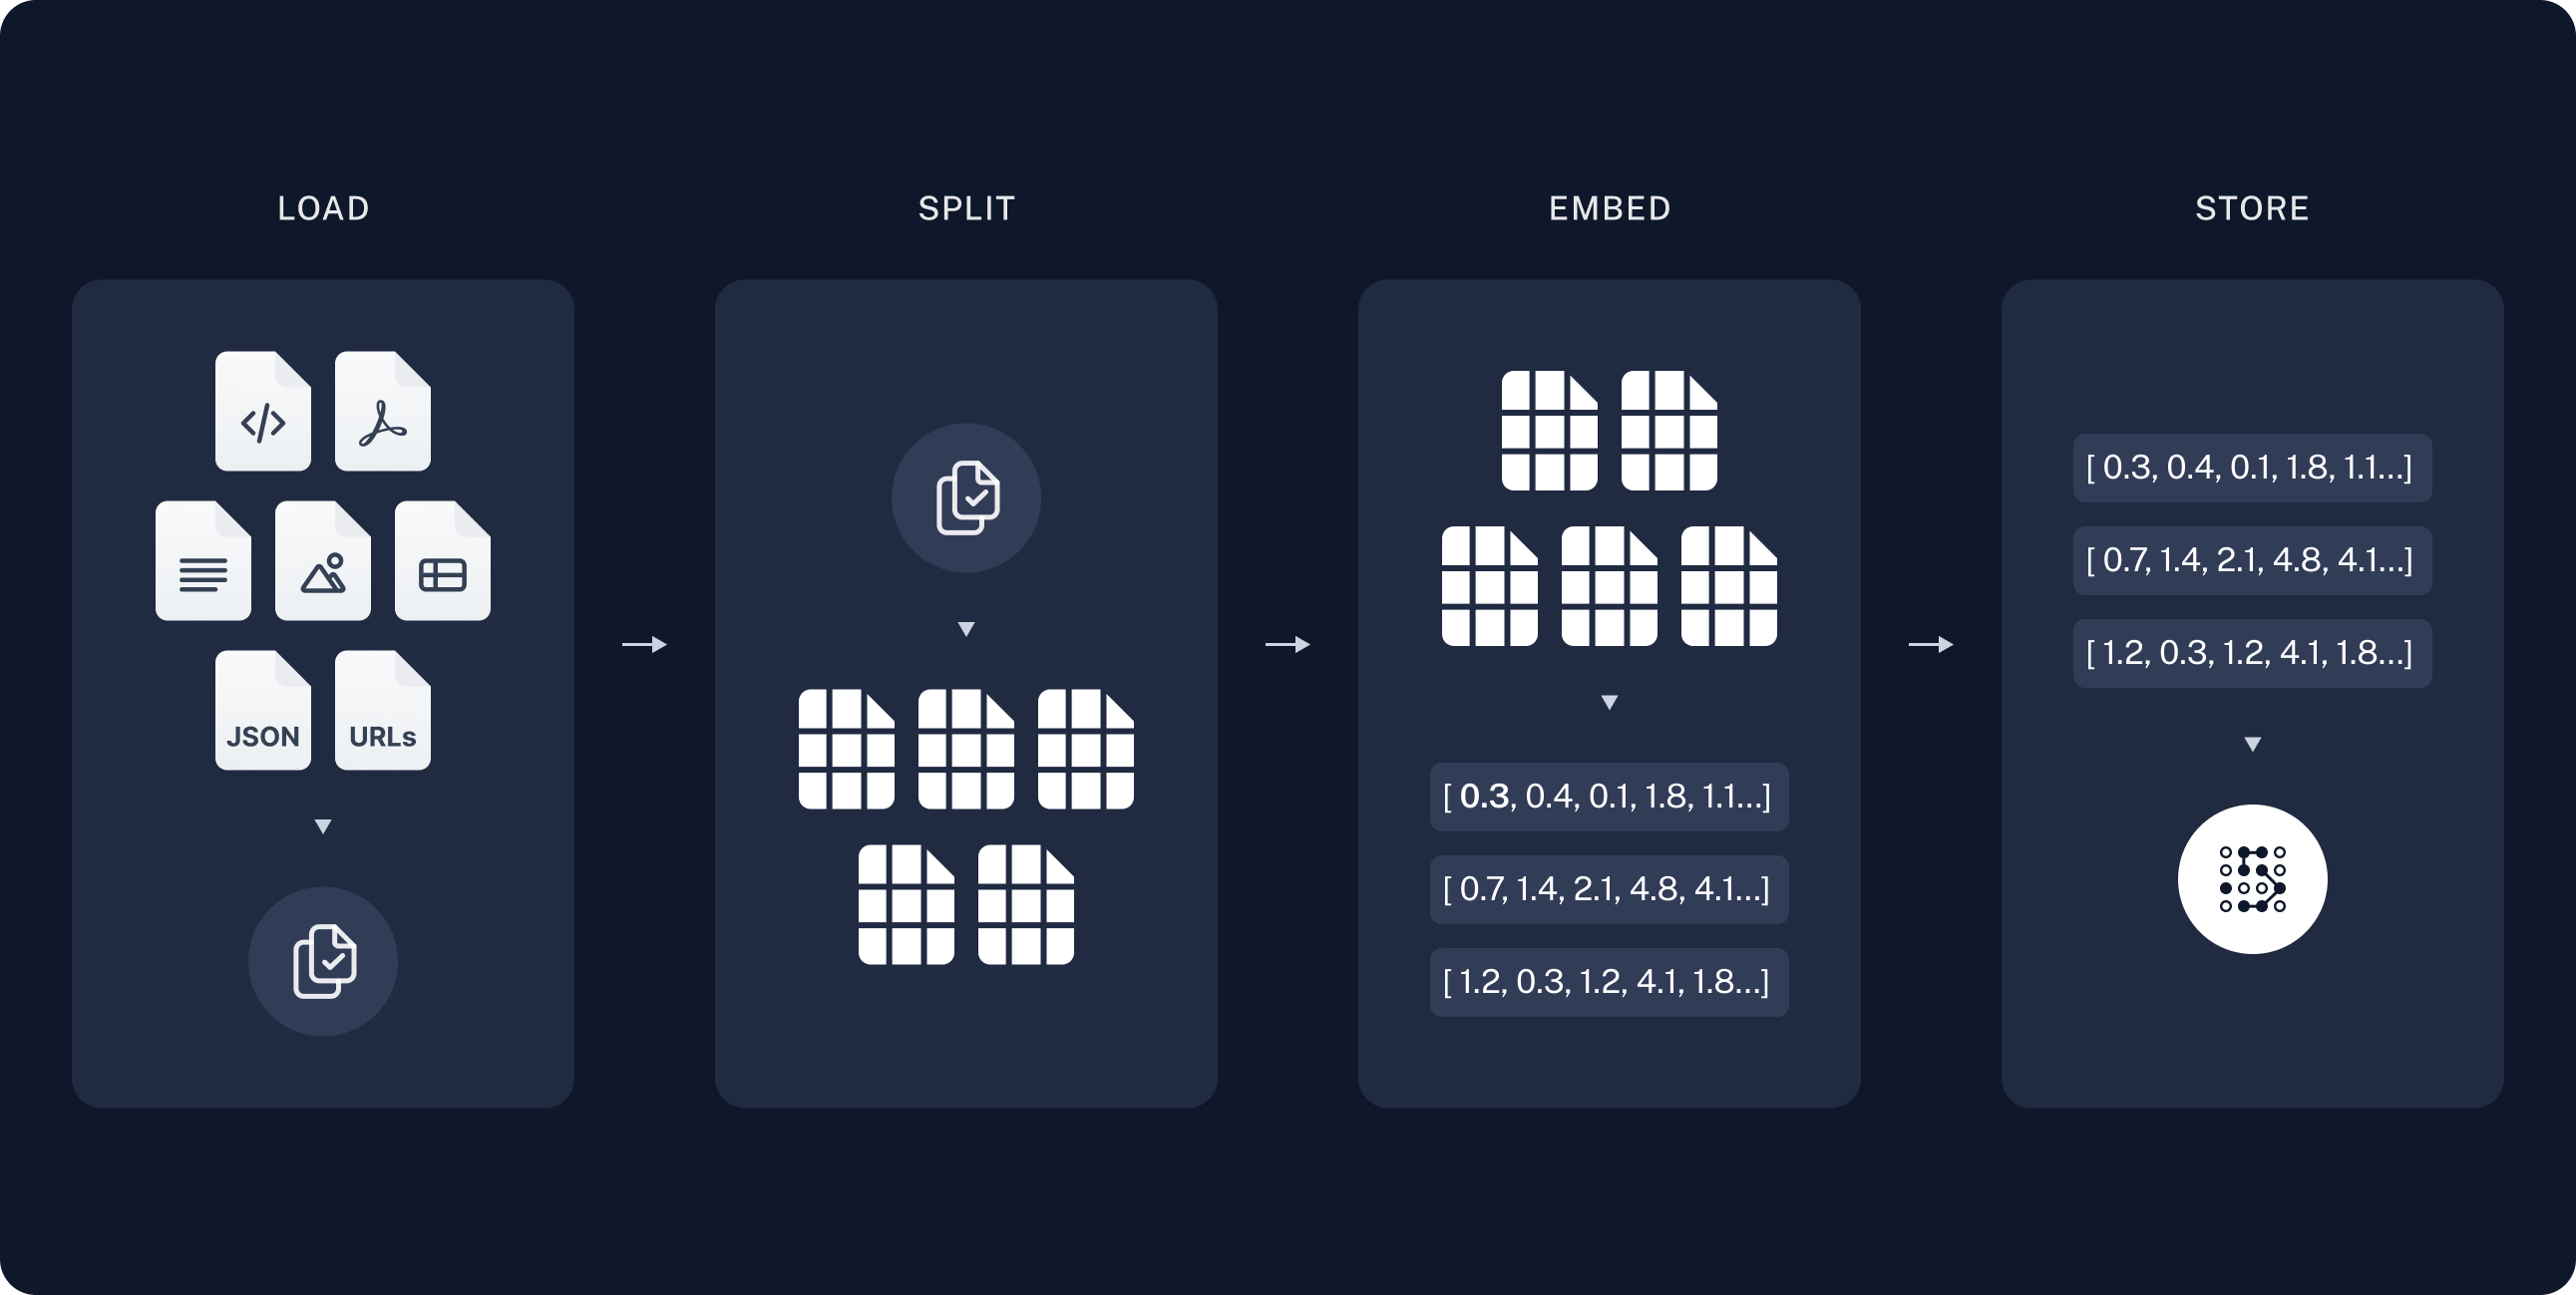


### Retrieval and generation
4. **Retrieve**: Given a user input, relevant splits are retrieved from storage using a [Retriever](https://python.langchain.com/docs/concepts/retrievers/).
5. **Generate**: A [ChatModel](https://python.langchain.com/docs/concepts/chat_models/) / [LLM](https://python.langchain.com/docs/concepts/text_llms/) produces an answer using a prompt that includes both the question with the retrieved data

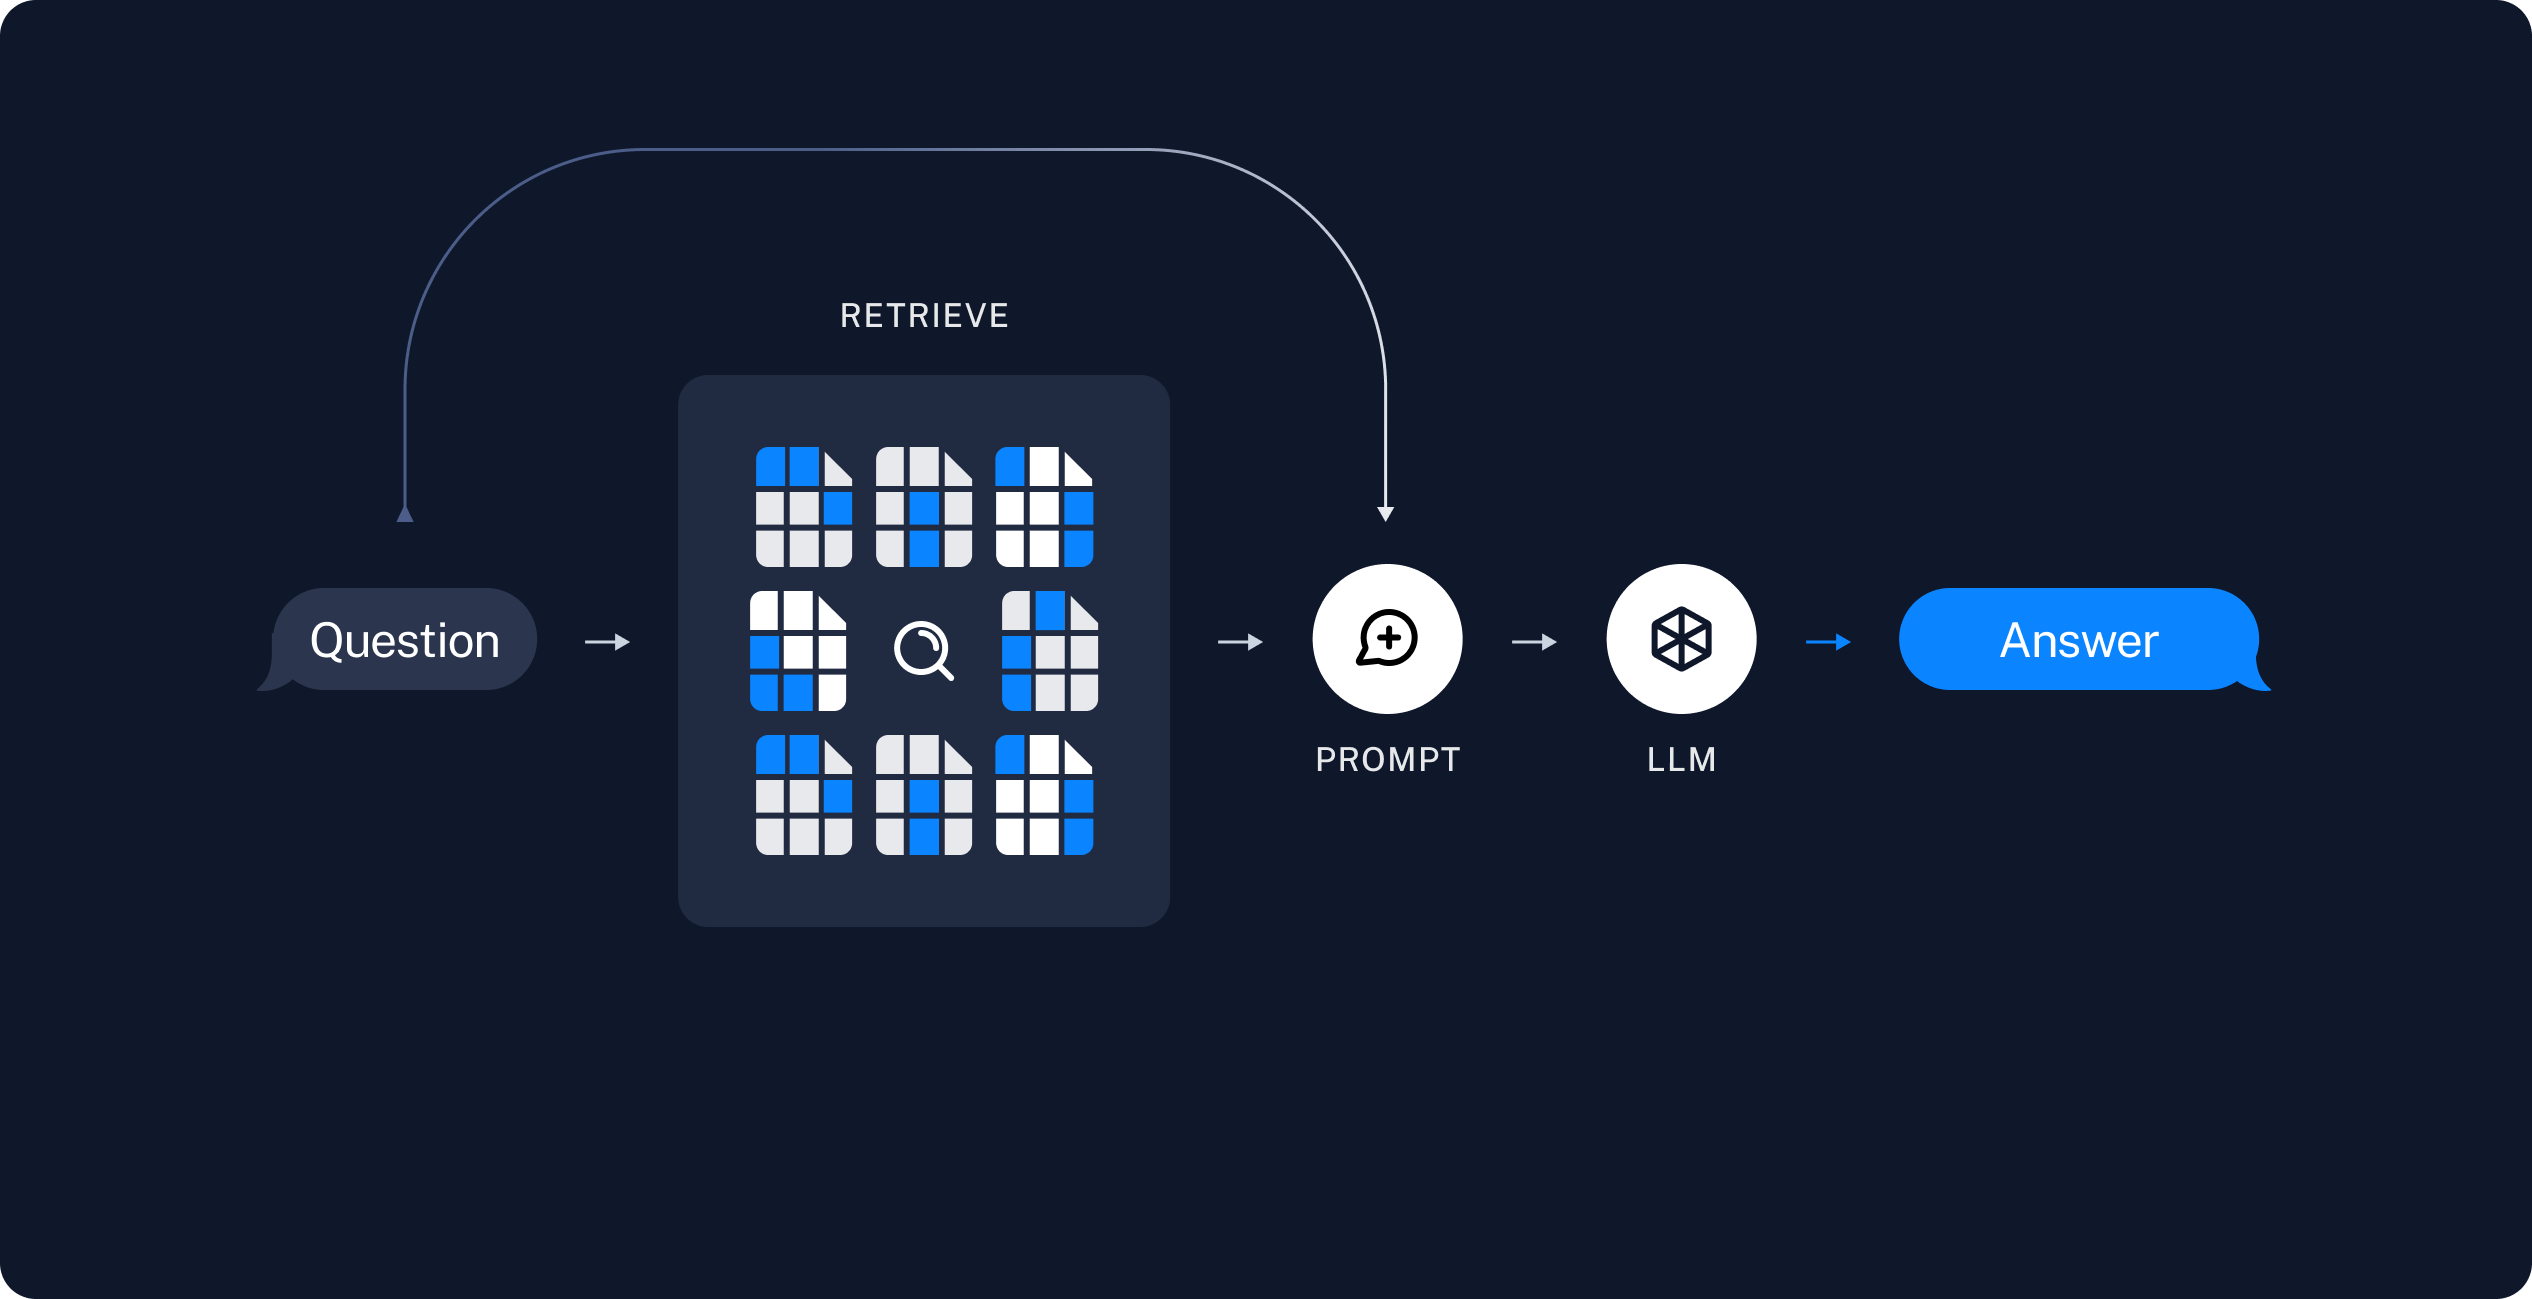

We start by importing the core components needed for our RAG pipeline:

In [ ]:
from langchain_community.document_loaders import TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.chains import create_retrieval_chain


📦 What each component does:

- TextLoader: Loads raw text documents.
- RecursiveCharacterTextSplitter: Splits documents into chunks intelligently, preserving context.
- HuggingFaceEmbeddings: Uses local SentenceTransformers to generate embeddings.
- Chroma: An in-memory vector store for fast similarity search.
- ChatPromptTemplate: Template system to format prompts for the LLM.
- create_stuff_documents_chain: A chain that stuffs retrieved documents into a prompt for generation.
- create_retrieval_chain: Combines retrieval and generation into one pipeline.


##🤖 Configure the Language Model (LLM)
We now initialize the OpenAI LLM using LangChain’s wrapper. This allows us to seamlessly integrate GPT-based models into our RAG pipeline.
- ChatOpenAI is a LangChain interface for OpenAI’s chat models (e.g., GPT-3.5, GPT-4).
- You can configure parameters like temperature, model name, or API key.
- Here we simply pass in the API key to get started.

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(openai_api_key=api_key)

## 📄 Load the Text Document
We begin by loading the input text file (essay.txt) using LangChain's TextLoader. The result is a document object containing the raw content of the file.

In [ ]:
# Load data
loader = TextLoader("essay.txt")
docs = loader.load()

## ✂️ Split the Text into Chunks
Next, we split the loaded document into smaller chunks using RecursiveCharacterTextSplitter. This ensures that each chunk fits within token limits and preserves as much semantic structure as possible.

In [ ]:
# Split text into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000,
    chunk_overlap=300
)

documents = text_splitter.split_documents(docs)

### 📊 Rule of Thumb:
A common overlap is **10–20% of the chunk size**.

For chunk_size = 2000, this means:

🔁 200–400 characters of overlap is a good range

✅ Why use overlap:

- **Avoid information loss**: Important info at the end of one chunk might be cut off and missed entirely if not repeated in the start of the next chunk.
- **Better semantic continuity**: Some concepts span multiple sentences or paragraphs. Overlap ensures the model sees more complete context.
- **Improved embeddings**: Overlapping helps prevent abrupt context shifts, making the chunk’s semantic meaning more coherent.

✅ chunk_size=2000 means:
You're setting the maximum chunk size to 2000 characters (not tokens).

✅ chunk_overlap=300 means:
Each new chunk will overlap the previous one by 300 characters—ensuring that some context is carried over between chunks.

With these settings:

- Chunk 1: characters 0 to 2000
- Chunk 2: characters 1700 to 3700
- Chunk 3: characters 3400 to 5400
…and so on.

Each new chunk starts 300 characters before where the previous chunk ended, helping preserve semantic flow.

## 📊 Visualize Number, Size, and Overlap of Chunks
After splitting the document, we can analyze how many chunks were created, the average length, and whether there's any overlap.

In [ ]:
# Visualize chunk statistics
chunk_lengths = [len(doc.page_content) for doc in documents]

print(f"Total number of chunks: {len(documents)}")
print(f"Average chunk length: {sum(chunk_lengths) / len(chunk_lengths):.2f} characters")
print(f"Minimum chunk length: {min(chunk_lengths)} characters")
print(f"Maximum chunk length: {max(chunk_lengths)} characters")


Total number of chunks: 44
Average chunk length: 1768.77 characters
Minimum chunk length: 1045 characters
Maximum chunk length: 1986 characters


As you may have noticed, despite the defined chunk length of 2000 characters, the actual size of the chunks varies.

✅ Why chunks vary in size with RecursiveCharacterTextSplitter

Even with a set chunk_size, LangChain tries to preserve semantic structure. It:

1. First tries to split by "\n\n" (paragraphs)
2. Then by "\n" (lines)
3. Then by punctuation like ". " or spaces
4. Falls back to character-level cuts if nothing else works

This can cause **variation in chunk lengths**, as it balances structure vs. length.

# Components/Chains

Now that our text is split into chunks, we can move on to setting up the **RAG pipeline** components.

In LangChain, predictable components are called [Chains](https://python.langchain.com/api_reference/langchain/chains.html) .

These are compositions of individual steps or components

We'll need to choose appropriate components from LangChain's suite of integrations.


###1. Configure the Language Model (LLM)
We now initialize the OpenAI LLM using LangChain’s wrapper. This allows us to seamlessly integrate GPT-based models into our RAG pipeline.
- ChatOpenAI is a LangChain interface for OpenAI’s chat models (e.g., GPT-3.5, GPT-4).
- You can configure parameters like temperature, model name, or API key.
- Here we simply pass in the API key to get started.

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(openai_api_key=api_key)

###2. Define the embedding model for LangChain

In [ ]:
# Define the embedding model for LangChain
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

### 3. Create an in-memory vector store using Chroma


In [ ]:
# Create an in-memory vector store using Chroma
vector_store = Chroma.from_documents(documents, embeddings)

### 4. Define a retriever interface



In [ ]:
retriever = vector_store.as_retriever()

### 5. Define prompt template

In [ ]:
# Define prompt template
prompt = ChatPromptTemplate.from_template("""Answer the following question based only on the provided context:

<context>
{context}
</context>

Question: {input}""")


##🧩 What Each Component Does in the RAG Pipeline:
- HuggingFaceEmbeddings: Loads the SentenceTransformer model (all-MiniLM-L6-v2) to embed each document chunk.
- Chroma.from_documents: Stores all chunk embeddings in an in-memory vector database for fast similarity search.
- as_retriever(): Creates a retriever interface, which we’ll use to find the most relevant chunks given a question.
- ChatPromptTemplate: Defines how to format prompts for the language model, injecting both the retrieved context and the user question.

The prompt is designed to clearly separate the context and the question, instructing the model to base its answer only on the provided content.



## 🔄 Build and Run the Retrieval-Augmented Generation Chain

Now we bring everything together into a **retrieval chain** that answers questions using the documents we embedded earlier.

In [ ]:
# Create a retrieval chain to answer questions
document_chain = create_stuff_documents_chain(llm, prompt)
retrieval_chain = create_retrieval_chain(retriever, document_chain)

response = retrieval_chain.invoke({"input": "What were the two main things the author worked on before college?"})
print("\nLangChain RAG Response:")
print(response["answer"])




LangChain RAG Response:
The two main things the author worked on before college were writing and programming.


## 🧩 What’s happening here:
- create_stuff_documents_chain(llm, prompt):
Creates a chain that combines the retrieved documents and "stuffs" them into the prompt template for the LLM.

- create_retrieval_chain(retriever, document_chain):
Wraps the retriever and the LLM prompt chain into a single pipeline that can take a user query and return an answer.

- .invoke({"input": ...}):
Sends a user query through the retrieval + generation pipeline.

- response["answer"]:
Extracts the generated answer from the response dictionary.

### **Define a More Detailed Prompt and Run the Full RAG Pipeline**
We define a prompt that encourages the language model to give detailed, context-based answers, and run the complete RAG flow.

In [ ]:
# Define prompt template
prompt = ChatPromptTemplate.from_template("""Answer the following question based only on the provided context.
Please be detailed in your response and include specific information from the context.

<context>
{context}
</context>

Question: {input}""")

# Create a retrieval chain to answer questions
document_chain = create_stuff_documents_chain(llm, prompt)
retrieval_chain = create_retrieval_chain(retriever, document_chain)
response = retrieval_chain.invoke({"input": "What were the two main things the author worked on before college?"})
print("\nLangChain RAG Response:")
print(response["answer"])



LangChain RAG Response:
Before college, the two main things the author worked on were writing and programming. The author did not write essays, but rather short stories. The first programs the author tried writing were on an IBM 1401 computer used for data processing in 9th grade, where they used an early version of Fortran. The language required typing programs on punch cards, stacking them in the card reader, and pressing a button to load the program into memory and run it. The author describes not being able to figure out what to do with the IBM 1401, as the input to programs was data stored on punched cards and they did not have any data stored on punched cards. The author also applied to art schools and was accepted to Rhode Island School of Design (RISD) for the BFA program, where they had to do the foundation classes in fundamental subjects like drawing, color, and design.


## 🔍 What’s happening:
- **Prompt refinement**:
We ask the model to be detailed and pull specific facts from the provided context, which leads to richer answers.
- **Retrieval + Generation**:
The pipeline retrieves the most relevant document chunks and feeds them into the prompt for the LLM to answer.
- **Final output**:
The model’s answer is printed, grounded solely in the retrieved context (no external knowledge).
